Dataset loaded successfully
Dataset shape: (6435, 12)
Shape after feature engineering: (6255, 16)

Preview of engineered features:
    Store       Date  Weekly_Sales  Sales_Lag_1  Sales_Lag_2  Sales_Lag_4  \
4       1 2010-03-05    1554806.68   1409727.59   1611968.17   1643690.90   
5       1 2010-03-12    1439541.59   1554806.68   1409727.59   1641957.44   
6       1 2010-03-19    1472515.79   1439541.59   1554806.68   1611968.17   
7       1 2010-03-26    1404429.92   1472515.79   1439541.59   1409727.59   
8       1 2010-04-02    1594968.28   1404429.92   1472515.79   1554806.68   
9       1 2010-04-09    1545418.53   1594968.28   1404429.92   1439541.59   
10      1 2010-04-16    1466058.28   1545418.53   1594968.28   1472515.79   
11      1 2010-04-23    1391256.12   1466058.28   1545418.53   1404429.92   
12      1 2010-04-30    1425100.71   1391256.12   1466058.28   1594968.28   
13      1 2010-05-07    1603955.12   1425100.71   1391256.12   1545418.53   

    Sales_Rolling_4  

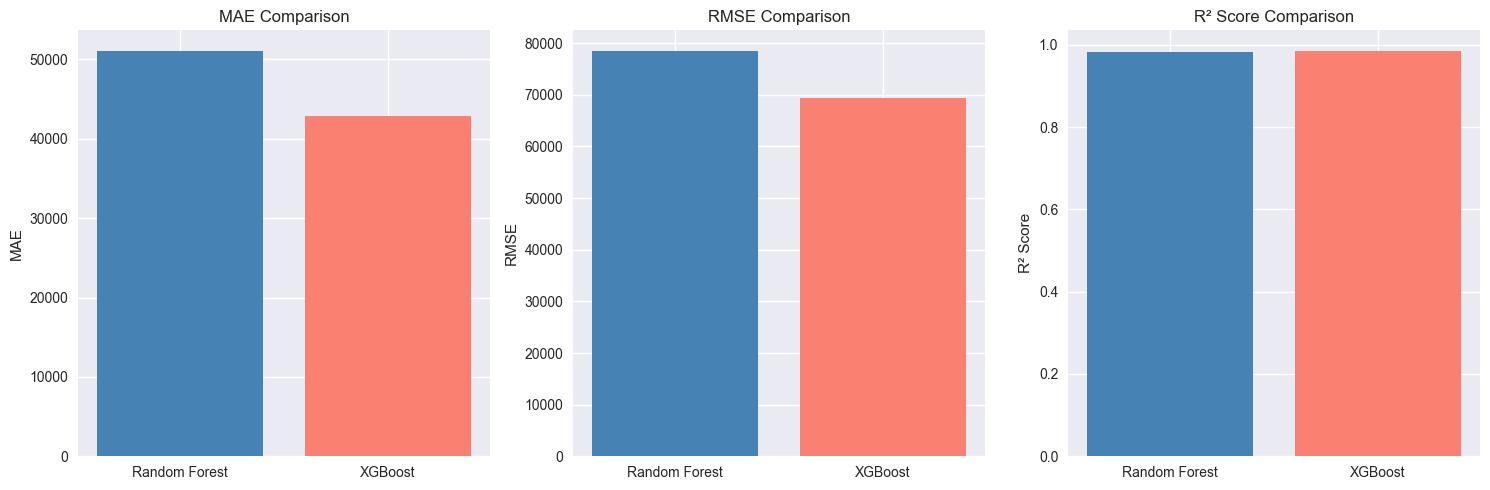

C:\Users\sahoo\AppData\Local\Temp\ipykernel_8900\4031810511.py:196: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


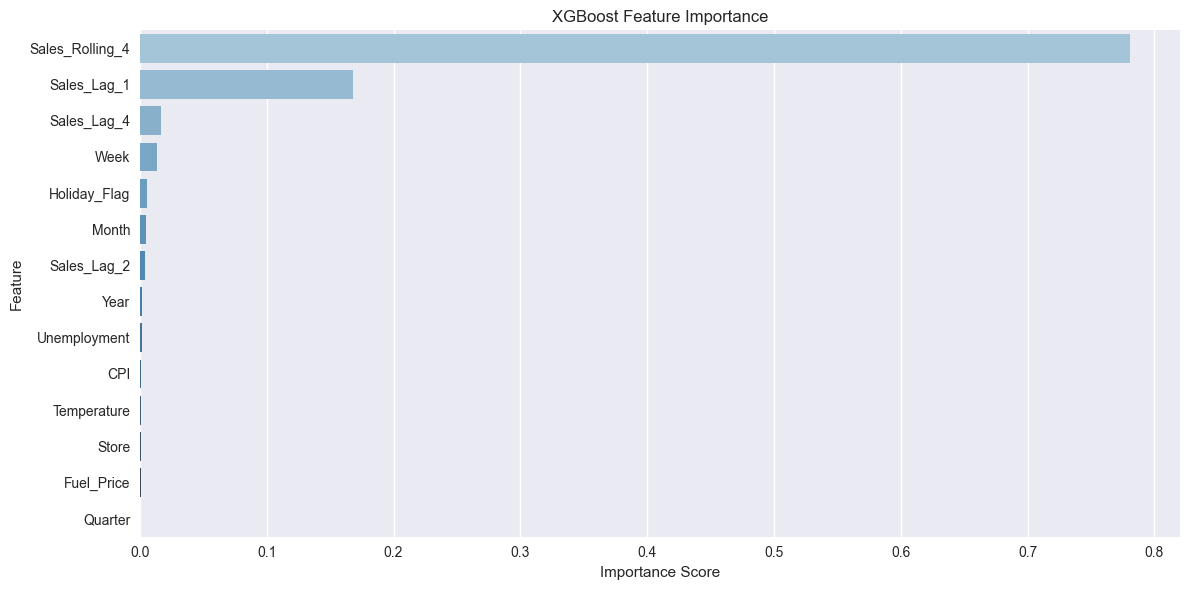


Top 5 Important Features
            Feature  Importance
13  Sales_Rolling_4    0.781164
10      Sales_Lag_1    0.168020
12      Sales_Lag_4    0.016719
8              Week    0.013461
1      Holiday_Flag    0.005421


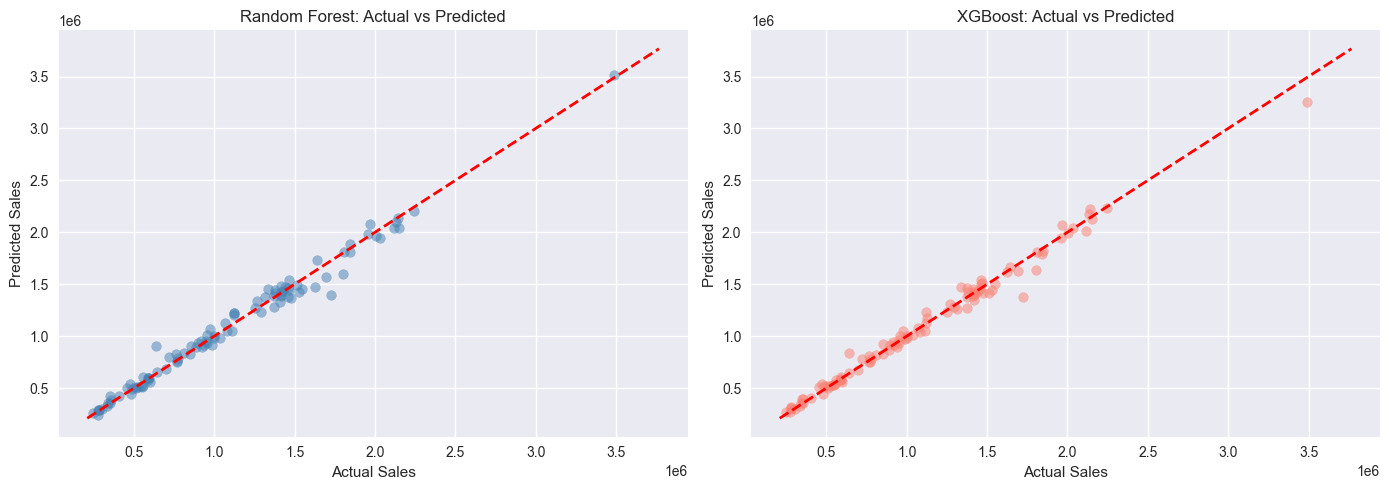


Models saved successfully
Saved files:
→ models/random_forest_model.pkl
→ models/xgboost_model.pkl


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

import joblib
import os

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

# ---------------- LOAD DATA ---------------- #

# Reading Walmart sales dataset
df = pd.read_csv('../data/Walmart.csv')

# Converting Date column into datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Creating additional date-based features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

# ---------------- FEATURE ENGINEERING ---------------- #

# Sorting values for proper lag calculations
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

# Previous sales values
df['Sales_Lag_1'] = df.groupby('Store')['Weekly_Sales'].shift(1)
df['Sales_Lag_2'] = df.groupby('Store')['Weekly_Sales'].shift(2)
df['Sales_Lag_4'] = df.groupby('Store')['Weekly_Sales'].shift(4)

# Rolling average feature
df['Sales_Rolling_4'] = (
    df.groupby('Store')['Weekly_Sales']
    .transform(lambda x: x.shift(1).rolling(window=4).mean())
)

# Removing rows containing NaN values
df = df.dropna()

print("Shape after feature engineering:", df.shape)

print("\nPreview of engineered features:")
print(
    df[
        [
            'Store',
            'Date',
            'Weekly_Sales',
            'Sales_Lag_1',
            'Sales_Lag_2',
            'Sales_Lag_4',
            'Sales_Rolling_4'
        ]
    ].head(10)
)

# ---------------- SELECT FEATURES ---------------- #

features = [
    'Store',
    'Holiday_Flag',
    'Temperature',
    'Fuel_Price',
    'CPI',
    'Unemployment',
    'Year',
    'Month',
    'Week',
    'Quarter',
    'Sales_Lag_1',
    'Sales_Lag_2',
    'Sales_Lag_4',
    'Sales_Rolling_4'
]

target = 'Weekly_Sales'

X = df[features]
y = df[target]

print("\nFeature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

# ---------------- TRAIN TEST SPLIT ---------------- #

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# ---------------- RANDOM FOREST MODEL ---------------- #

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions
rf_predictions = rf_model.predict(X_test)

# Evaluation metrics
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("\nRandom Forest Performance")
print(f"MAE  : ${rf_mae:,.2f}")
print(f"RMSE : ${rf_rmse:,.2f}")
print(f"R²   : {rf_r2:.4f}")

# ---------------- XGBOOST MODEL ---------------- #

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# Predictions
xgb_predictions = xgb_model.predict(X_test)

# Evaluation metrics
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_r2 = r2_score(y_test, xgb_predictions)

print("\nXGBoost Performance")
print(f"MAE  : ${xgb_mae:,.2f}")
print(f"RMSE : ${xgb_rmse:,.2f}")
print(f"R²   : {xgb_r2:.4f}")

# ---------------- MODEL COMPARISON ---------------- #

results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'MAE': [rf_mae, xgb_mae],
    'RMSE': [rf_rmse, xgb_rmse],
    'R² Score': [rf_r2, xgb_r2]
})

print("\nModel Comparison")
print(results.to_string(index=False))

# Visual comparison of metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['MAE', 'RMSE', 'R² Score']
colors = ['steelblue', 'salmon']

for i, metric in enumerate(metrics):
    axes[i].bar(results['Model'], results[metric], color=colors)
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)

plt.tight_layout()
plt.savefig('../outputs/graphs/07_model_comparison.png',
            dpi=300,
            bbox_inches='tight')
plt.show()

# ---------------- FEATURE IMPORTANCE ---------------- #

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df,
    palette='Blues_d'
)

plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.tight_layout()

plt.savefig('../outputs/graphs/08_feature_importance.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

print("\nTop 5 Important Features")
print(importance_df.head())

# ---------------- ACTUAL VS PREDICTED ---------------- #

# Taking random sample points for cleaner visualization
sample_idx = np.random.choice(len(y_test), 100, replace=False)

plt.figure(figsize=(14, 5))

# Random Forest plot
plt.subplot(1, 2, 1)

plt.scatter(
    y_test.iloc[sample_idx],
    rf_predictions[sample_idx],
    alpha=0.5,
    color='steelblue'
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.title('Random Forest: Actual vs Predicted')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')

# XGBoost plot
plt.subplot(1, 2, 2)

plt.scatter(
    y_test.iloc[sample_idx],
    xgb_predictions[sample_idx],
    alpha=0.5,
    color='salmon'
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.title('XGBoost: Actual vs Predicted')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')

plt.tight_layout()

plt.savefig('../outputs/graphs/09_actual_vs_predicted.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

# ---------------- SAVE MODELS ---------------- #

# Creating models folder if not already present
os.makedirs('../models', exist_ok=True)

# Saving trained models
joblib.dump(rf_model, '../models/random_forest_model.pkl')
joblib.dump(xgb_model, '../models/xgboost_model.pkl')

print("\nModels saved successfully")
print("Saved files:")
print("→ models/random_forest_model.pkl")
print("→ models/xgboost_model.pkl")